In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "ai4i2020.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "stephanmatzka/predictive-maintenance-dataset-ai4i-2020",
  file_path,
)

print("First 5 records:", df.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_18564\2854168570.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 510k/510k [00:05<00:00, 93.1kB/s]

First 5 records:    UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    

In [3]:
# Step 2. Understand the dataset:-
# Identify:

# Features/input columns
# Target column
# Numerical columns
# Categorical columns
# Missing values
# Duplicate rows


df

df.columns

df.select_dtypes(include="number").columns

df.select_dtypes(include='object').columns

# target= machine failures

df.isnull().sum()

df.duplicated().sum()

# percantage of missing Values
(df.isnull().sum() / len(df)) * 100

C:\Users\HP\AppData\Local\Temp\ipykernel_18564\1967269104.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


UDI                        0.0
Product ID                 0.0
Type                       0.0
Air temperature [K]        0.0
Process temperature [K]    0.0
Rotational speed [rpm]     0.0
Torque [Nm]                0.0
Tool wear [min]            0.0
Machine failure            0.0
TWF                        0.0
HDF                        0.0
PWF                        0.0
OSF                        0.0
RNF                        0.0
dtype: float64

In [4]:
# Step 3. Data Cleaning

# Remove duplicates
# Handle missing values
# Correct data types
# Check outliers
# Remove unnecessary columns

df.duplicated().sum()

df.isnull().sum()

df.dtypes

df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


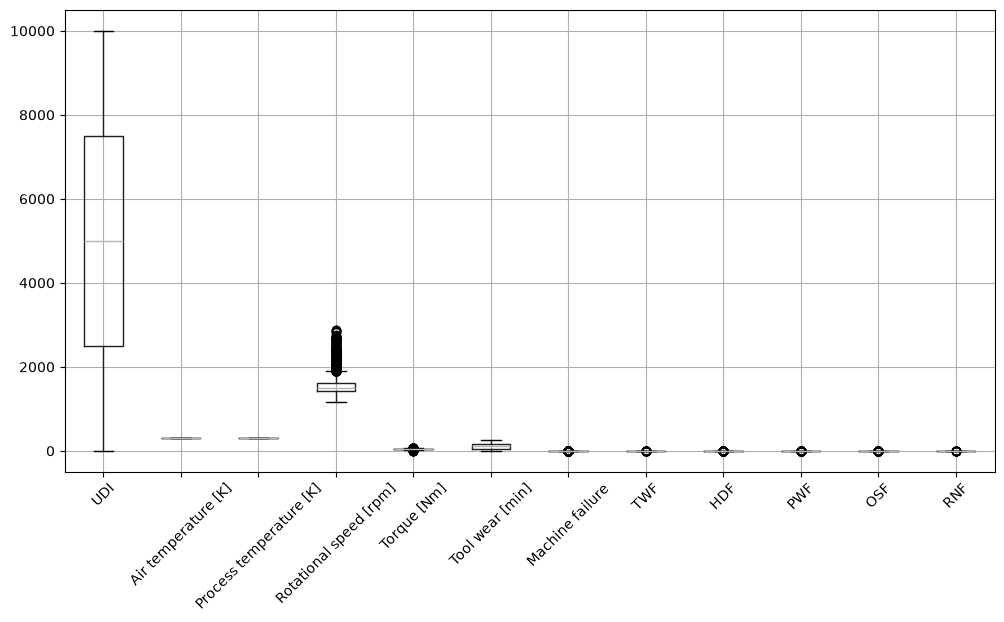

Air temperature [K] : 0 outliers
Process temperature [K] : 0 outliers
Rotational speed [rpm] : 418 outliers
Torque [Nm] : 69 outliers
Tool wear [min] : 0 outliers


In [5]:
df.select_dtypes(include="number").boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()


# or checking outliers using iqr method
numeric_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers), "outliers")


In [6]:
df.boxplot(column="Torque [Nm]")

df.boxplot(column="Rotational speed [rpm]")

<Axes: >

In [7]:
# Step 4. EDA
# Analyze:

# Distribution of machine failures
# Temperature vs failure
# Torque vs Machine Failure
# Rotational Speed vs Machine Failure
# Correlation
# Failure frequency

In [8]:
# Distribution of machine failures
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

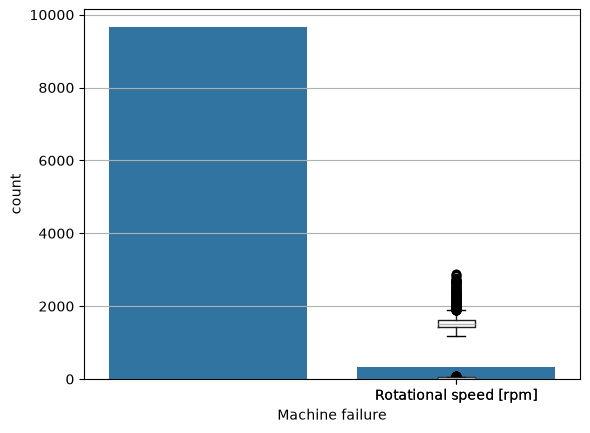

In [9]:
sns.countplot(x="Machine failure", data=df)
plt.show()

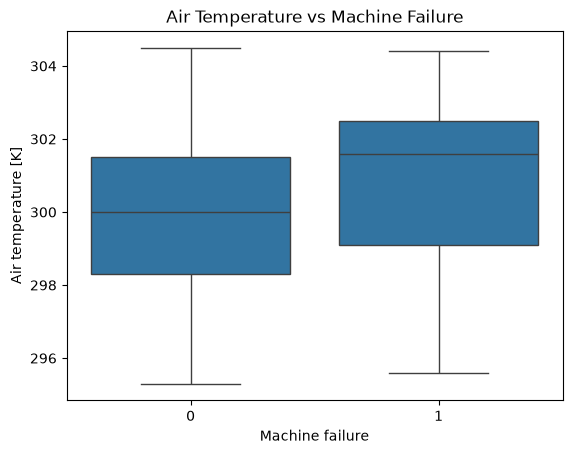

In [10]:
# Temperature vs failure
sns.boxplot(x="Machine failure", y="Air temperature [K]", data=df)

plt.title("Air Temperature vs Machine Failure")
plt.show()

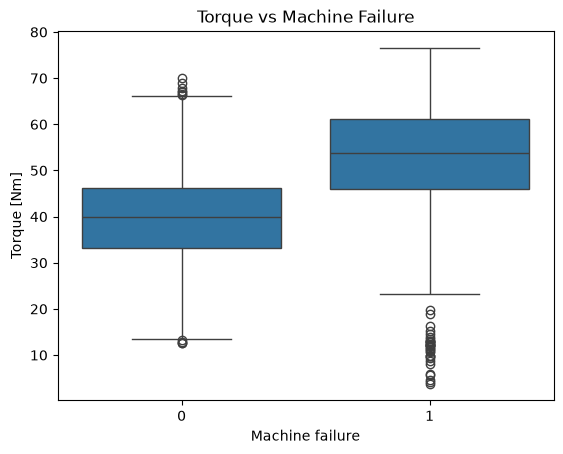

In [11]:
# Torque vs Machine Failure
sns.boxplot(x="Machine failure", y="Torque [Nm]", data=df)

plt.title("Torque vs Machine Failure")
plt.show()


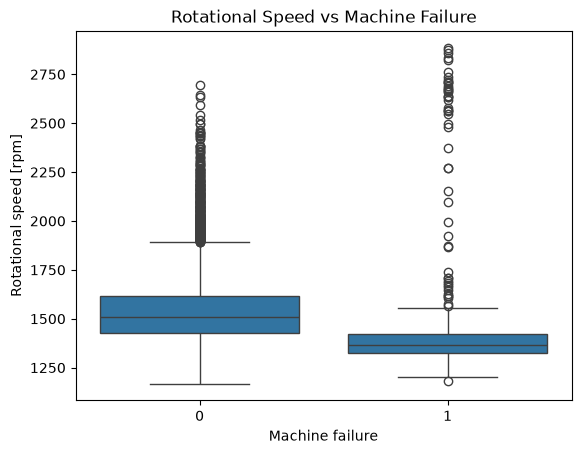

In [12]:
# Rotational Speed vs Machine Failure
sns.boxplot(x="Machine failure",y="Rotational speed [rpm]",data=df)
plt.title("Rotational Speed vs Machine Failure")
plt.show()

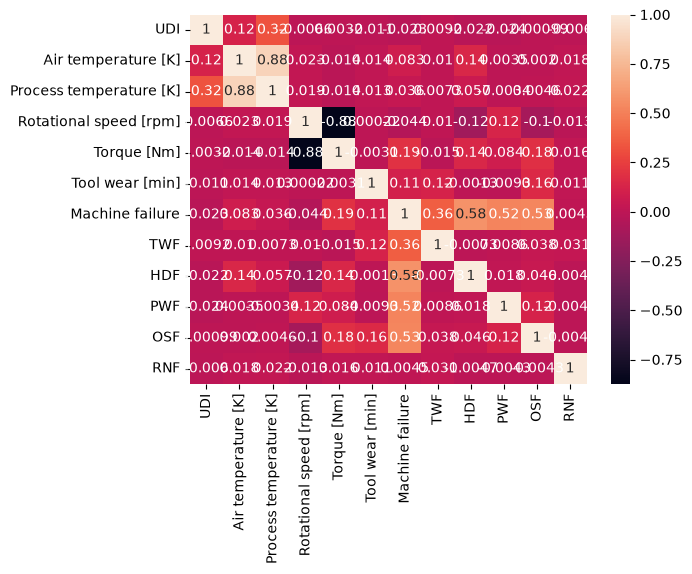

In [13]:
# Correlation
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [14]:
# Failure frequency
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]

failure_frequency = df[failure_types].sum()

print(failure_frequency)

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


In [15]:
# Step 5. Create useful features

In [16]:
# 1. temperature difference
df["Temperature difference"] = df["Process temperature [K]"] - df["Air temperature [K]"]

In [17]:
# 2. Average Temperature
df["Average Temperature"] = (df["Process temperature [K]"] + df["Air temperature [K]"]) / 2

In [18]:
# 3. Power-related Feature
df["Power"]=(    df["Rotational speed [rpm]"] * df["Torque [Nm]"]
)

In [19]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature difference,Average Temperature,Power
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,303.35,66382.8
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,303.45,65190.4
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,303.30,74001.2
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,303.40,56603.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,303.45,56320.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,303.60,47318.0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,303.65,51897.6
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,303.80,54943.0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,303.85,68288.0


In [20]:
df.shape

(10000, 17)

In [21]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Temperature difference', 'Average Temperature', 'Power'],
      dtype='str')

In [22]:
# Define X anfd y
X = df.drop(
    ["Machine failure", "UDI", "Product ID",
     "TWF", "HDF", "PWF", "OSF", "RNF"],
    axis=1
)

y = df["Machine failure"]
X

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature difference,Average Temperature,Power
0,M,298.1,308.6,1551,42.8,0,10.5,303.35,66382.8
1,L,298.2,308.7,1408,46.3,3,10.5,303.45,65190.4
2,L,298.1,308.5,1498,49.4,5,10.4,303.30,74001.2
3,L,298.2,308.6,1433,39.5,7,10.4,303.40,56603.5
4,L,298.2,308.7,1408,40.0,9,10.5,303.45,56320.0
...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,9.6,303.60,47318.0
9996,H,298.9,308.4,1632,31.8,17,9.5,303.65,51897.6
9997,M,299.0,308.6,1645,33.4,22,9.6,303.80,54943.0
9998,H,299.0,308.7,1408,48.5,25,9.7,303.85,68288.0


In [23]:
# Phase 4 — Classification
# Step 6. Create the failure prediction model

In [24]:
print(X.shape)
print(X.head())
print(y.value_counts())

(10000, 9)
  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Temperature difference  Average Temperature  \
0         42.8                0                    10.5               303.35   
1         46.3                3                    10.5               303.45   
2         49.4                5                    10.4               303.30   
3         39.5                7                    10.4               303.40   
4         40.0                9                    10.5               303.45   

     Power  
0  66382.8  
1

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Type"] = le.fit_transform(df["Type"])

In [26]:
X = df.drop(
    ["Machine failure", "UDI", "Product ID",
     "TWF", "HDF", "PWF", "OSF", "RNF"],
    axis=1
)

y = df["Machine failure"]

In [27]:
print(df.dtypes)

UDI                          int64
Product ID                     str
Type                         int64
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
Temperature difference     float64
Average Temperature        float64
Power                      float64
dtype: object


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.86
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1932
           1       0.18      0.88      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000



In [32]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn= knn.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.976
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.34      0.49        68

    accuracy                           0.98      2000
   macro avg       0.93      0.67      0.74      2000
weighted avg       0.97      0.98      0.97      2000



In [34]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)



In [35]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.983
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.77      0.72      0.74        68

    accuracy                           0.98      2000
   macro avg       0.88      0.86      0.87      2000
weighted avg       0.98      0.98      0.98      2000



In [36]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9905


In [38]:
print("Random Forest Accuracy:", accuracy_rf)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9905
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.93      0.78      0.85        68

    accuracy                           0.99      2000
   macro avg       0.96      0.89      0.92      2000
weighted avg       0.99      0.99      0.99      2000



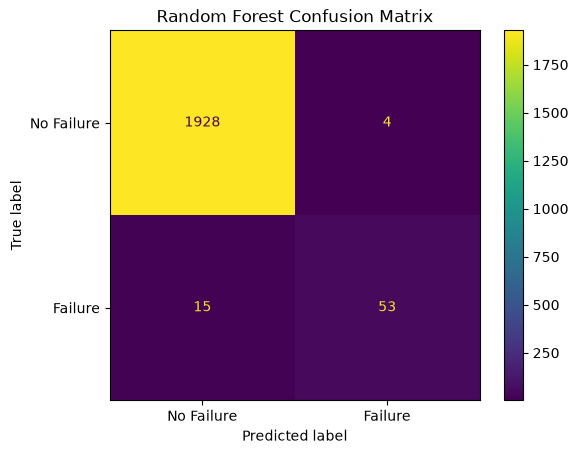

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [40]:
# Step 7. Evaluate the models

# Use:

# Confusion Matrix
# Accuracy
# Precision
# Recall
# F1 Score
# ROC-AUC

In [41]:
y_pred        # Logistic Regression
y_pred_knn    # KNN
y_pred_dt     # Decision Tree
y_pred_rf     # Random Forest

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [42]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [43]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("-" * 30)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

In [44]:
evaluate_model("Logistic Regression", y_test, y_pred)

evaluate_model("KNN", y_test, y_pred_knn)

evaluate_model("Decision Tree", y_test, y_pred_dt)

evaluate_model("Random Forest", y_test, y_pred_rf)


Logistic Regression
------------------------------
Confusion Matrix:
[[1660  272]
 [   8   60]]
Accuracy : 0.86
Precision: 0.18072289156626506
Recall   : 0.8823529411764706
F1 Score : 0.3

KNN
------------------------------
Confusion Matrix:
[[1929    3]
 [  45   23]]
Accuracy : 0.976
Precision: 0.8846153846153846
Recall   : 0.3382352941176471
F1 Score : 0.48936170212765956

Decision Tree
------------------------------
Confusion Matrix:
[[1917   15]
 [  19   49]]
Accuracy : 0.983
Precision: 0.765625
Recall   : 0.7205882352941176
F1 Score : 0.7424242424242424

Random Forest
------------------------------
Confusion Matrix:
[[1928    4]
 [  15   53]]
Accuracy : 0.9905
Precision: 0.9298245614035088
Recall   : 0.7794117647058824
F1 Score : 0.848


In [45]:
results = {
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
       }

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.8600   0.180723  0.882353  0.300000
1                  KNN    0.9760   0.884615  0.338235  0.489362
2        Decision Tree    0.9830   0.765625  0.720588  0.742424
3        Random Forest    0.9905   0.929825  0.779412  0.848000


In [46]:
# Step 8 — Create Downtime & Maintenance Cost
import numpy as np

rng = np.random.default_rng(42)

# base downtime hours by failure type (same lookup as before)
base_downtime = np.select(
    [
        df["TWF"] == 1,
        df["HDF"] == 1,
        df["PWF"] == 1,
        df["OSF"] == 1,
        df["RNF"] == 1
    ],
    [
        2,
        4,
        6,
        8,
        3
    ],
    default=0
)

# add noise so downtime isn't a perfectly deterministic lookup table:
# - failure rows get realistic variation around the base hours
# - non-failure rows get a small amount of slack (minor unplanned stoppages,
#   inspections, etc.) instead of a hard 0 for 97% of the data
noise = np.where(
    base_downtime > 0,
    rng.normal(0, 0.8, len(df)),
    rng.uniform(0, 0.3, len(df))
)

df["Downtime_Hours"] = (base_downtime + noise).clip(min=0).round(2)

In [47]:
df[["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF", "Downtime_Hours"]].head()

,Machine failure,TWF,HDF,PWF,OSF,RNF,Downtime_Hours
0,0,0,0,0,0,0,0.23
1,0,0,0,0,0,0,0.07
2,0,0,0,0,0,0,0.25
3,0,0,0,0,0,0,0.05
4,0,0,0,0,0,0,0.11


In [48]:
# Create Maintenance_Cost
# add noise to represent real variation in labor/parts cost, so the
# regression target isn't a 100% deterministic formula of the features
cost_noise = rng.normal(0, 150, len(df))

df["Maintenance_Cost"] = (
    df["Downtime_Hours"] * 1000
    + df["Tool wear [min]"] * 5
    + cost_noise
).clip(lower=0).round(2)

In [49]:
df[[
    "Downtime_Hours",
    "Tool wear [min]",
    "Maintenance_Cost"
]].head()

,Downtime_Hours,Tool wear [min],Maintenance_Cost
0,0.23,0,0.00
1,0.07,3,291.35
2,0.25,5,469.27
3,0.05,7,420.45
4,0.11,9,306.73


In [50]:
# predicating maintaince cost
X_reg = df.drop(
    [
        "Maintenance_Cost",
        "Downtime_Hours",
        "Machine failure",
        "UDI",
        "Product ID",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ],
    axis=1
)
y_reg = df["Maintenance_Cost"]

In [51]:
print(X_reg.columns)
print(y_reg.head())

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Temperature difference', 'Average Temperature', 'Power'],
      dtype='str')
0      0.00
1    291.35
2    469.27
3    420.45
4    306.73
Name: Maintenance_Cost, dtype: float64


In [52]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [53]:
from sklearn.preprocessing import StandardScaler

# Ridge/Lasso (and to a lesser extent Linear Regression) are sensitive to
# feature scale, so scale the regression features the same way we scaled
# the classification features earlier
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [54]:
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()

lr_reg.fit(X_train_reg_scaled, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ -10.13, 20.48, -3.1 ,..., -45.76, 10.76,-1235.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,873.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[160.68,148.93, 89.66,..., 9.95, 0. , 0. ]"


In [55]:
y_pred_lr = lr_reg.predict(X_test_reg_scaled)
print(y_pred_lr[:10])

[1197.23191201  976.80422657  798.80937362   34.10243105 1070.29490109
 1708.89298874 1619.19936701 1767.07912036  232.61324442   35.92403965]


In [56]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
mae = mean_absolute_error(y_test_reg, y_pred_lr)

mse = mean_squared_error(y_test_reg, y_pred_lr)

rmse = mean_squared_error(
    y_test_reg,
    y_pred_lr
) ** 0.5

r2 = r2_score(y_test_reg, y_pred_lr)

In [57]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 426.4467172201574
MSE : 778763.2433527014
RMSE: 882.4756332911983
R²  : 0.2978022779210461


In [58]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)

y_pred_bagging = bagging.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score, classification_report

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bagging))
print(classification_report(y_test, y_pred_bagging))

Bagging Accuracy: 0.9905
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.93      0.78      0.85        68

    accuracy                           0.99      2000
   macro avg       0.96      0.89      0.92      2000
weighted avg       0.99      0.99      0.99      2000



In [60]:
# Random Forest Regressor — predicting Maintenance_Cost, not classification
# (this was previously a duplicate RandomForestClassifier by mistake)
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg.fit(X_train_reg_scaled, y_train_reg)

y_pred_rf_reg = rf_reg.predict(X_test_reg_scaled)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test_reg, y_pred_rf_reg)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

print("Random Forest Regressor")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

Random Forest Regressor
MAE : 226.78351135
MSE : 262702.1439397641
RMSE: 512.5447726196845
R2  : 0.7631258939936717


In [62]:
# Regression model comparison
reg_results = {
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [mae, mae_rf],
    "MSE": [mse, mse_rf],
    "RMSE": [rmse, rmse_rf],
    "R2": [r2, r2_rf]
}

reg_results_df = pd.DataFrame(reg_results)
print(reg_results_df)

                     Model         MAE            MSE        RMSE        R2
0        Linear Regression  426.446717  778763.243353  882.475633  0.297802
1  Random Forest Regressor  226.783511  262702.143940  512.544773  0.763126


In [63]:
# code done time for fast api

In [64]:
import joblib
import os

# Create folder for saved models
os.makedirs("models", exist_ok=True)

# Classification artifacts
joblib.dump(rf, "models/failure_model.pkl")
joblib.dump(scaler, "models/classification_scaler.pkl")
joblib.dump(le, "models/type_encoder.pkl")

# Regression artifacts
joblib.dump(rf_reg, "models/cost_model.pkl")
joblib.dump(scaler_reg, "models/regression_scaler.pkl")

print("All models saved successfully!")

All models saved successfully!


In [65]:
import os

print(os.listdir("models"))

['classification_scaler.pkl', 'cost_model.pkl', 'failure_model.pkl', 'regression_scaler.pkl', 'type_encoder.pkl']


In [66]:
failure_model = joblib.load("models/failure_model.pkl")
cost_model = joblib.load("models/cost_model.pkl")
regression_scaler = joblib.load("models/regression_scaler.pkl")

print("Models loaded successfully!")

Models loaded successfully!


In [67]:
# Step 10 — Export processed data for SQL
# This CSV feeds load_data.py, which loads it into PostgreSQL
import os

os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/ai4i_processed.csv", index=False)
print("Saved data/processed/ai4i_processed.csv with", len(df), "rows")

Saved data/processed/ai4i_processed.csv with 10000 rows
